<a href="https://colab.research.google.com/github/rraidero/ifes-mestrado/blob/main/%5BRodrigoRaider%5D_Trabalho_de_Reconhecimento_de_Padr%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook: Predição de Preços de Carros Usados

```
Aluno: Rodrigo Raider de Oliveira
Disciplina: Reconhecimento de Padrões
Professor: Francisco de Assis Boldt
```

## Base de Dados

Este notebook utiliza dados do desafio Kaggle **Playground Series Season 4 Episode 9 - Predict Future Sales**. O objetivo desta competição é prever o preço de venda de carros usados.

Os dados contêm informações detalhadas sobre carros, incluindo suas características como marca, modelo, ano, condição, quilometragem, tipo de combustível, tipo de transmissão, etc., e o preço de venda correspondente. A tarefa é construir um modelo que possa prever o preço de um carro com base nessas características.

Referência: *Walter Reade and Ashley Chow. Regression of Used Car Prices. https://kaggle.com/competitions/playground-series-s4e9, 2024. Kaggle.*

### Objetivos do Notebook
* Compreender o dataset de carros usados.
* Realizar a preparação e limpeza dos dados.
* Explorar visualmente o dataset para identificar padrões e relacionamentos.
* Aplicar diversas técnicas de aprendizado de máquina para construir modelos preditivos.
* Avaliar e comparar o desempenho dos modelos.
* Justificar as escolhas metodológicas e interpretar os resultados.

## Importação do dataset

In [ ]:
# Montar o Google Drive no ambiente do Google Colab
from google.colab import drive

# Faz a autenticação e conecta o Google Drive ao Colab
drive.mount('/content/drive')

# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


# Definir o caminho base onde os dados estão armazenados no Google Drive
base_path = '/content/drive/MyDrive/Estudos/0-Ifes-Mestrado/Reconhecimento de Padrões/Trabalho-Final/data'


# Verificar se o caminho informado realmente existe
if not os.path.exists(base_path):
    # Caso o caminho não exista, exibe um aviso para o usuário
    print(f"Aviso: O caminho '{base_path}' não existe. Crie a pasta ou ajuste o caminho.")
else:
    # Caso exista, informa que o diretório foi encontrado corretamente
    print(f"O caminho dos dados '{base_path}' existe.")


# Carregar os arquivos CSV para DataFrames do pandas

# Carrega o conjunto de dados de treinamento
train_df = pd.read_csv(os.path.join(base_path, 'train.csv'))

# Carrega o conjunto de dados de teste
test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))

# Carrega o arquivo de exemplo de submissão
sample_submission_df = pd.read_csv(
    os.path.join(base_path, 'sample_submission.csv')
)


# Exibir mensagem indicando que os datasets foram carregados com sucesso
print("Datasets carregados com sucesso.")

# Mostrar as 5 primeiras linhas do DataFrame de treinamento
print("\nPrimeiras 5 linhas de train_df:")

# head() retorna as primeiras linhas do DataFrame
print(train_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
O caminho dos dados '/content/drive/MyDrive/Estudos/0-Ifes-Mestrado/Reconhecimento de Padrões/Trabalho-Final/data' existe.
Datasets carregados com sucesso.

Primeiras 5 linhas de train_df:
   id          brand              model  model_year  milage      fuel_type  \
0   0           MINI      Cooper S Base        2007  213000       Gasoline   
1   1        Lincoln              LS V8        2002  143250       Gasoline   
2   2      Chevrolet  Silverado 2500 LT        2002  136731  E85 Flex Fuel   
3   3        Genesis   G90 5.0 Ultimate        2017   19500       Gasoline   
4   4  Mercedes-Benz        Metris Base        2021    7388       Gasoline   

                                              engine  \
0       172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel   
1       252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel   
2  320.0HP 5.3L 8 Cylinder Engine Flex Fuel C

### Carregamento e Visão Geral dos Dados
* Exibir as primeiras linhas.
* Verificar informações básicas do DataFrame.
* Verificar as dimensões do dataset.

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [ ]:
train_df.describe()

,id,model_year,milage,price
count,188533.000000,188533.000000,188533.000000,1.885330e+05
mean,94266.000000,2015.829998,65705.295174,4.387802e+04
std,54424.933488,5.660967,49798.158076,7.881952e+04
min,0.000000,1974.000000,100.000000,2.000000e+03
25%,47133.000000,2013.000000,24115.000000,1.700000e+04
50%,94266.000000,2017.000000,57785.000000,3.082500e+04
75%,141399.000000,2020.000000,95400.000000,4.990000e+04
max,188532.000000,2024.000000,405000.000000,2.954083e+06


In [ ]:
# Seleciona apenas colunas do tipo object (texto/string)
colunas_object = train_df.select_dtypes(include=['object']).columns

# Percorre cada coluna e imprime a quantidade de valores únicos
for coluna in colunas_object:
    qtd_unicos = train_df[coluna].nunique()
    print(f"Coluna: {coluna}")
    print(f"Quantidade de valores distintos: {qtd_unicos}")
    print("-" * 40)

Coluna: brand
Quantidade de valores distintos: 57
----------------------------------------
Coluna: model
Quantidade de valores distintos: 1897
----------------------------------------
Coluna: fuel_type
Quantidade de valores distintos: 7
----------------------------------------
Coluna: engine
Quantidade de valores distintos: 1117
----------------------------------------
Coluna: transmission
Quantidade de valores distintos: 52
----------------------------------------
Coluna: ext_col
Quantidade de valores distintos: 319
----------------------------------------
Coluna: int_col
Quantidade de valores distintos: 156
----------------------------------------
Coluna: accident
Quantidade de valores distintos: 2
----------------------------------------
Coluna: clean_title
Quantidade de valores distintos: 1
----------------------------------------


id - identificador único de cada veículo no dataset.

brand - marca do veículo, o dataset possui 57 valores distintos.

model - modelo do veículo, o dataset possui 1897 valores distintos.

model_year - ano do modelo/fabricação do veículo.

milage - quilometragem rodada do veículo.

fuel_type - tipo de combustível utilizado pelo veículo, o dataset possui 7 valores distintos.

engine - especificação do motor do veículo (potência, cilindrada, tipo etc.), o dataset possui 1117 valores distintos.

transmission - tipo de transmissão/câmbio do veículo, o dataset possui 52 valores distintos.

ext_col - cor externa do veículo, o dataset possui 319 valores distintos.

int_col - cor interna/acabamento interno do veículo, o dataset possui 156 valores distintos.

accident - indica se o veículo possui histórico de acidente, o dataset possui 2 valores distintos.

clean_title - indica se o veículo possui documentação/título regularizado (“clean title”), o dataset possui 1 valor distinto.

price - preço do veículo.

In [ ]:
#Verificar quantidade de valores nulo no conjunto de treinamento
train_df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,5083
engine,0
transmission,0
ext_col,0
int_col,0


In [ ]:
#Verificar quantidade de valores nulo no conjunto de testes
test_df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,3383
engine,0
transmission,0
ext_col,0
int_col,0


In [ ]:
train_df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [ ]:
test_df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes


### Explorando as características

#### Marca (Brand)

Quantidade de valores distintos: 57
Quantidade de valores nulos: 0

['Acura' 'Alfa' 'Aston' 'Audi' 'BMW' 'Bentley' 'Bugatti' 'Buick'
 'Cadillac' 'Chevrolet' 'Chrysler' 'Dodge' 'FIAT' 'Ferrari' 'Ford' 'GMC'
 'Genesis' 'Honda' 'Hummer' 'Hyundai' 'INFINITI' 'Jaguar' 'Jeep' 'Karma'
 'Kia' 'Lamborghini' 'Land' 'Lexus' 'Lincoln' 'Lotus' 'Lucid' 'MINI'
 'Maserati' 'Maybach' 'Mazda' 'McLaren' 'Mercedes-Benz' 'Mercury'
 'Mitsubishi' 'Nissan' 'Plymouth' 'Polestar' 'Pontiac' 'Porsche' 'RAM'
 'Rivian' 'Rolls-Royce' 'Saab' 'Saturn' 'Scion' 'Subaru' 'Suzuki' 'Tesla'
 'Toyota' 'Volkswagen' 'Volvo' 'smart']


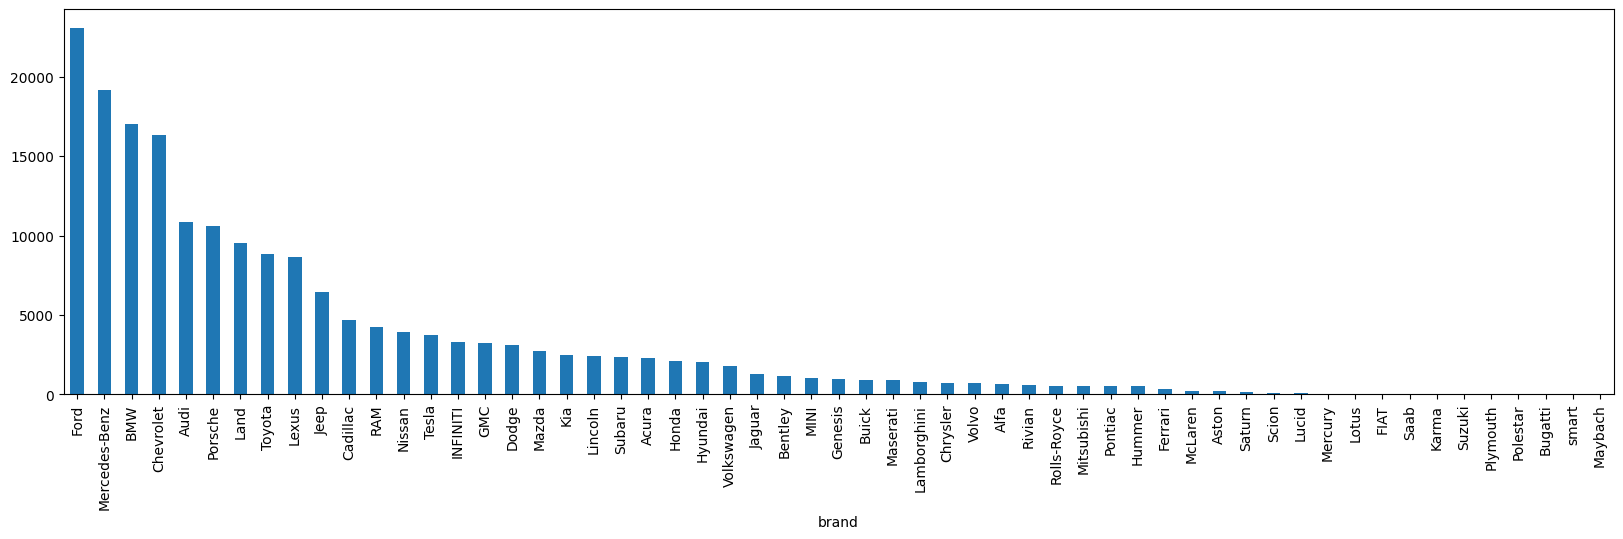

In [ ]:
todos_brand = pd.concat([
    train_df['brand'],
    test_df['brand']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_brand.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_brand.isnull().sum()}")

#Imprimir valores distintos ordenados pelo nome
print()
print(np.sort(todos_brand.unique()))

#Imprimir quantidade por marca
plt.figure(figsize=(20,5))
train_df['brand'].value_counts().plot(kind='bar')
plt.show()


del todos_brand

#### Modelo (Model)



In [ ]:
todos_modelos = pd.concat([
    train_df['model'],
    test_df['model']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_modelos.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_modelos.isnull().sum()}")

del todos_modelos

Quantidade de valores distintos: 1898
Quantidade de valores nulos: 0


#### Ano do Modelo (Model Year)

Quantidade de valores distintos: 36
Quantidade de valores nulos: 0

[1974 1982 1988 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]


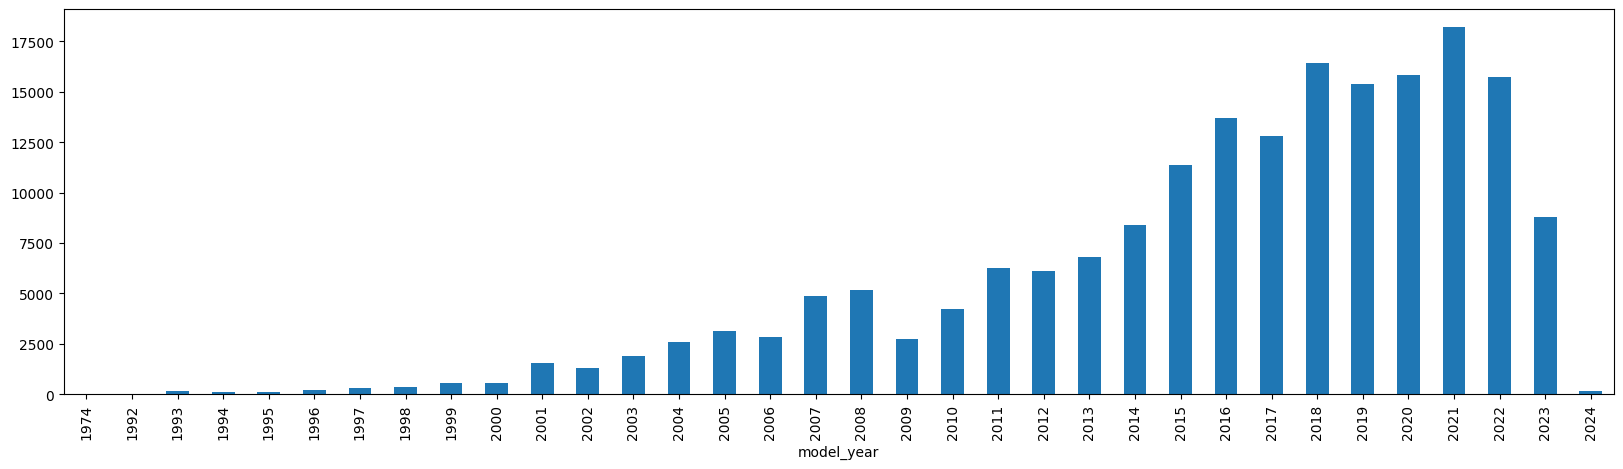

In [ ]:
todos_modelo_ano = pd.concat([
    train_df['model_year'],
    test_df['model_year']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_modelo_ano.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_modelo_ano.isnull().sum()}")

#Imprimir anos
print()
print(np.sort(todos_modelo_ano.unique()))

#Imprimir quantidade por ano (ordenado pelo ano)
plt.figure(figsize=(20,5))
train_df['model_year'].value_counts().sort_index().plot(kind='bar')
plt.show()

del todos_modelo_ano

#### Milhas percorridas (Milage)

In [ ]:
todos_milage = pd.concat([
    train_df['milage'],
    test_df['milage']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_milage.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_milage.isnull().sum()}")

del todos_milage

Quantidade de valores distintos: 8440
Quantidade de valores nulos: 0


#### Tipo de Combustível (Fuel Type)

Quantidade de valores distintos: 7
Quantidade de valores nulos: 8466

['Diesel' 'E85 Flex Fuel' 'Gasoline' 'Hybrid' 'Plug-In Hybrid'
 'not supported' '–']


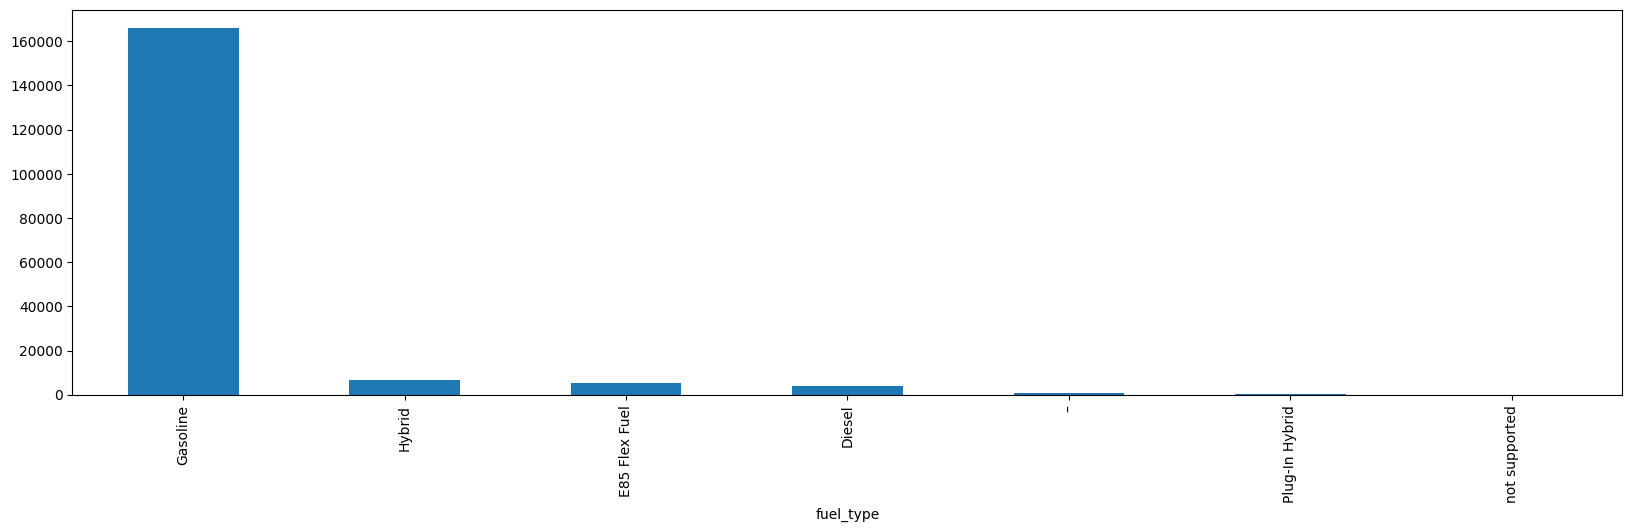

In [ ]:
todos_fuel_type = pd.concat([
    train_df['fuel_type'],
    test_df['fuel_type']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_fuel_type.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_fuel_type.isnull().sum()}")

#Imprimir tipos de combustível
print()
# Filter out NaN values before sorting
print(np.sort(todos_fuel_type.dropna().unique()))

#Imprimir quantidade por tipo de combustível
plt.figure(figsize=(20,5))
train_df['fuel_type'].value_counts().plot(kind='bar')
plt.show()

del todos_fuel_type

#### Motor (engine)

In [ ]:
test_df.head(20)['engine']

,engine
0,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel
1,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...
2,3.5L V6 24V PDI DOHC Twin Turbo
3,2.0 Liter TFSI
4,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel
5,285.0HP 4.8L 8 Cylinder Engine Gasoline Fuel
6,270.0HP 3.5L V6 Cylinder Engine Gasoline Fuel
7,3.8L V6 24V GDI DOHC
8,536.0HP 5.5L 8 Cylinder Engine Gasoline Fuel
9,365.0HP 3.3L V6 Cylinder Engine Gasoline Fuel


#### Transmissão (Transmission)


Quantidade de valores distintos: 52
Quantidade de valores nulos: 0

['1-Speed A/T' '1-Speed Automatic' '10-Speed A/T' '10-Speed Automatic'
 '10-Speed Automatic with Overdrive' '2' '2-Speed A/T' '2-Speed Automatic'
 '4-Speed A/T' '4-Speed Automatic' '5-Speed A/T' '5-Speed Automatic'
 '5-Speed M/T' '6 Speed At/Mt' '6 Speed Mt' '6-Speed' '6-Speed A/T'
 '6-Speed Automatic' '6-Speed Automatic with Auto-Shift'
 '6-Speed Electronically Controlled Automatic with O' '6-Speed M/T'
 '6-Speed Manual' '7-Speed' '7-Speed A/T' '7-Speed Automatic'
 '7-Speed Automatic with Auto-Shift' '7-Speed DCT Automatic' '7-Speed M/T'
 '7-Speed Manual' '8-SPEED A/T' '8-SPEED AT' '8-Speed A/T'
 '8-Speed Automatic' '8-Speed Automatic with Auto-Shift' '8-Speed Manual'
 '9-Speed A/T' '9-Speed Automatic' '9-Speed Automatic with Auto-Shift'
 'A/T' 'Automatic' 'Automatic CVT' 'CVT Transmission' 'CVT-F' 'F' 'M/T'
 'Manual' 'SCHEDULED FOR OR IN PRODUCTION' 'Single-Speed Fixed Gear'
 'Transmission Overdrive Switch' 'Transmis

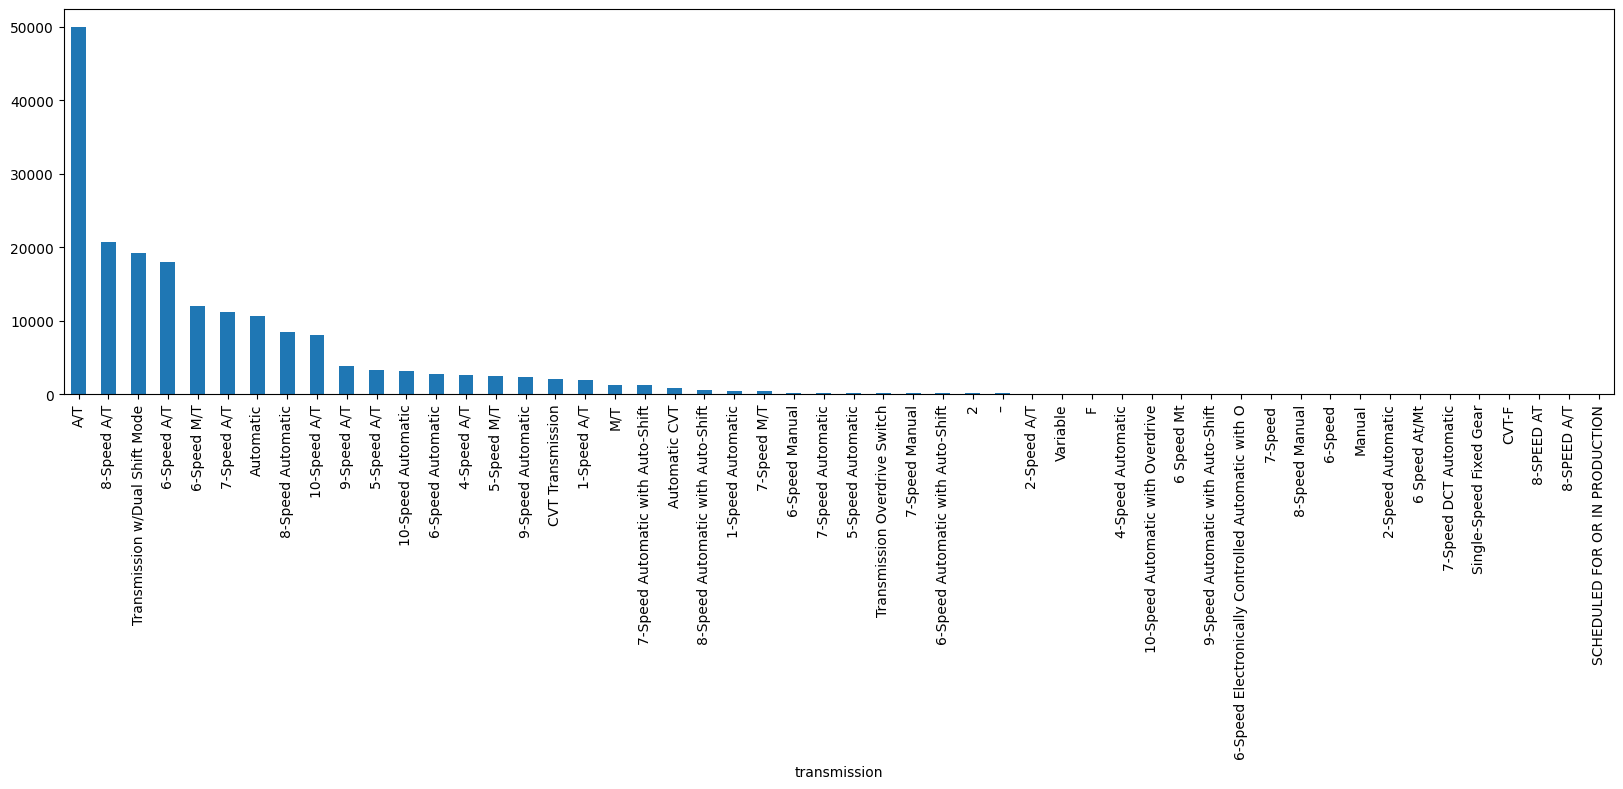

In [ ]:
todos_transmission = pd.concat([
    train_df['transmission'],
    test_df['transmission']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_transmission.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_transmission.isnull().sum()}")

#Imprimir tipos de transmissão
print()
# Filter out NaN values before sorting, though 'transmission' is not expected to have NaNs based on .info()
print(np.sort(todos_transmission.dropna().unique()))

#Imprimir quantidade por tipo de transmissão
plt.figure(figsize=(20,5))
train_df['transmission'].value_counts().plot(kind='bar')
plt.show()

del todos_transmission

#### Cor externa (Ext_col)


In [ ]:
todos_ext_col = pd.concat([
    train_df['ext_col'],
    test_df['ext_col']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_ext_col.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_ext_col.isnull().sum()}")

del todos_ext_col

Quantidade de valores distintos: 319
Quantidade de valores nulos: 0


#### Cor Interna (Int_col)


In [ ]:
todos_int_col = pd.concat([
    train_df['int_col'],
    test_df['int_col']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_int_col.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_int_col.isnull().sum()}")

del todos_int_col

Quantidade de valores distintos: 156
Quantidade de valores nulos: 0


#### Acidentes (Accident)


Quantidade de valores distintos: 2
Quantidade de valores nulos: 4084
Quantidade de strings vazias: 0

['At least 1 accident or damage reported' 'None reported']


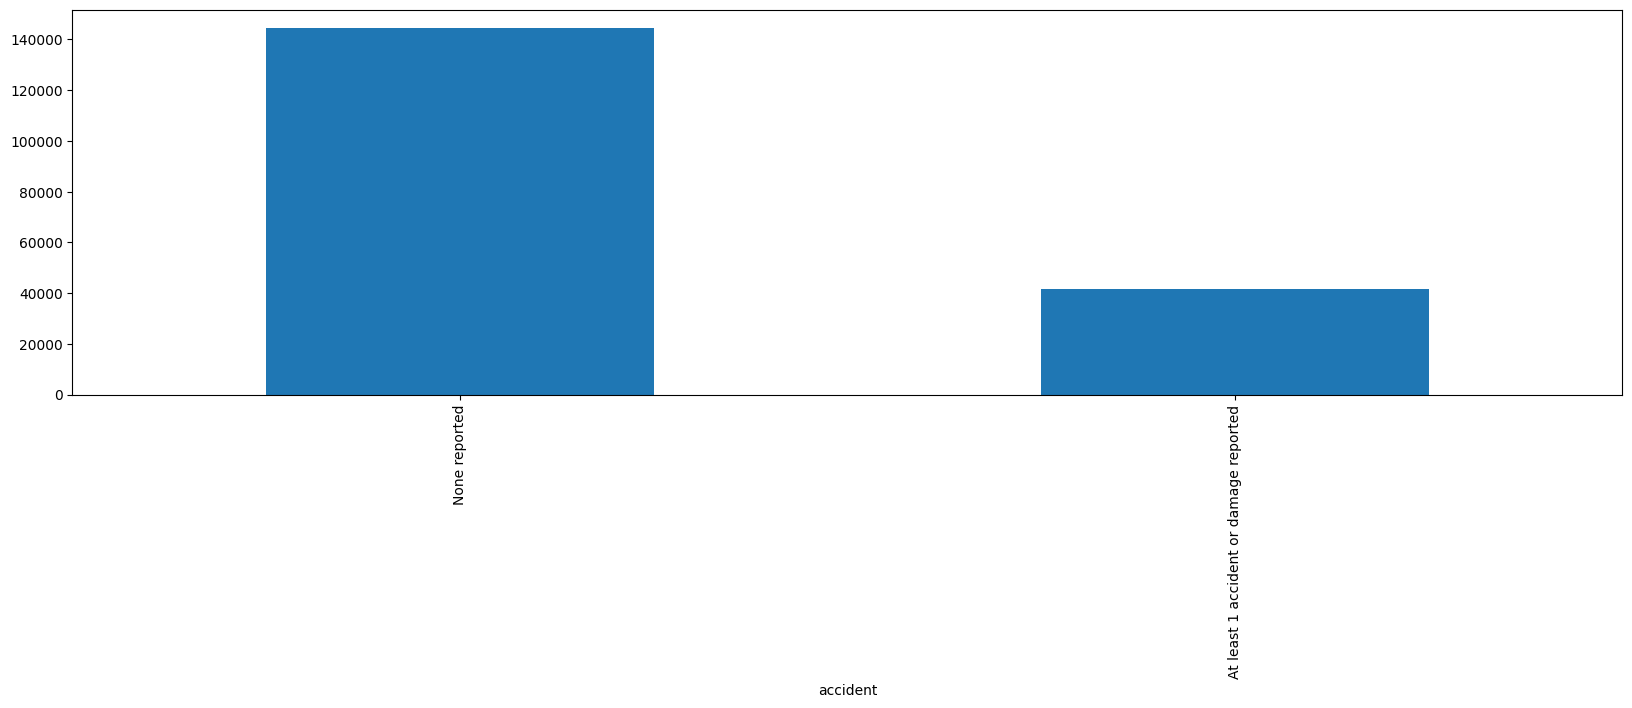

In [ ]:
todos_accident = pd.concat([
    train_df['accident'],
    test_df['accident']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_accident.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_accident.isnull().sum()}")

#Checar strings vazias
print(f"Quantidade de strings vazias: {(todos_accident == '').sum()}")

#Imprimir tipos de acidente
print()
# Filter out NaN values before sorting
print(np.sort(todos_accident.dropna().unique()))

#Imprimir quantidade por tipo de acidente
plt.figure(figsize=(20,5))
train_df['accident'].value_counts().plot(kind='bar')
plt.show()

del todos_accident

#### Situação Legal (Clean_title)

Quantidade de valores distintos: 1
Quantidade de valores nulos: 35658
Quantidade de strings vazias: 0

['Yes']


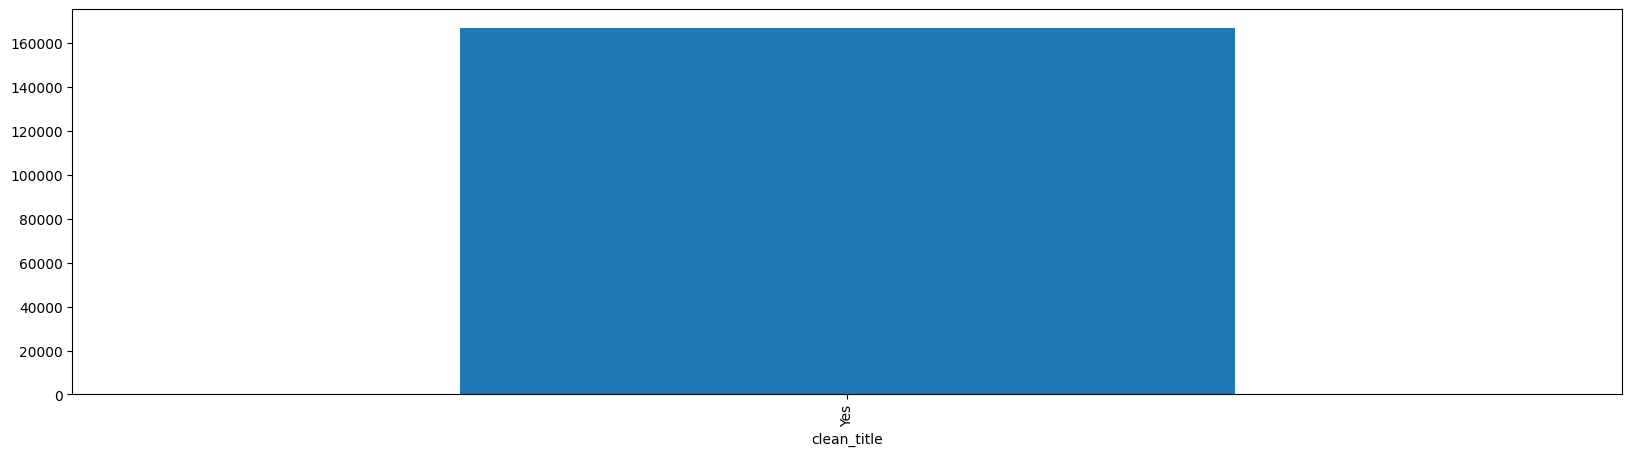

In [ ]:
todos_clean_title = pd.concat([
    train_df['clean_title'],
    test_df['clean_title']
], ignore_index=True)

#Imprimir quantidade de valores distintos
print(f"Quantidade de valores distintos: {todos_clean_title.nunique()}")

#Checar se existe valor nulo
print(f"Quantidade de valores nulos: {todos_clean_title.isnull().sum()}")

#Checar strings vazias
print(f"Quantidade de strings vazias: {(todos_clean_title == '').sum()}")

#Imprimir tipos de clean_title
print()
# Filter out NaN values before sorting
print(np.sort(todos_clean_title.dropna().unique()))

#Imprimir quantidade por tipo de clean_title
plt.figure(figsize=(20,5))
train_df['clean_title'].value_counts().plot(kind='bar')
plt.show()

del todos_clean_title

### Análise da Variável Alvo (`price`)

Vamos explorar a distribuição da variável alvo (`price`) para entender melhor os preços dos carros usados no dataset.

Estatísticas Descritivas da Variável Alvo (price):
count    1.885330e+05
mean     4.387802e+04
std      7.881952e+04
min      2.000000e+03
25%      1.700000e+04
50%      3.082500e+04
75%      4.990000e+04
max      2.954083e+06
Name: price, dtype: float64


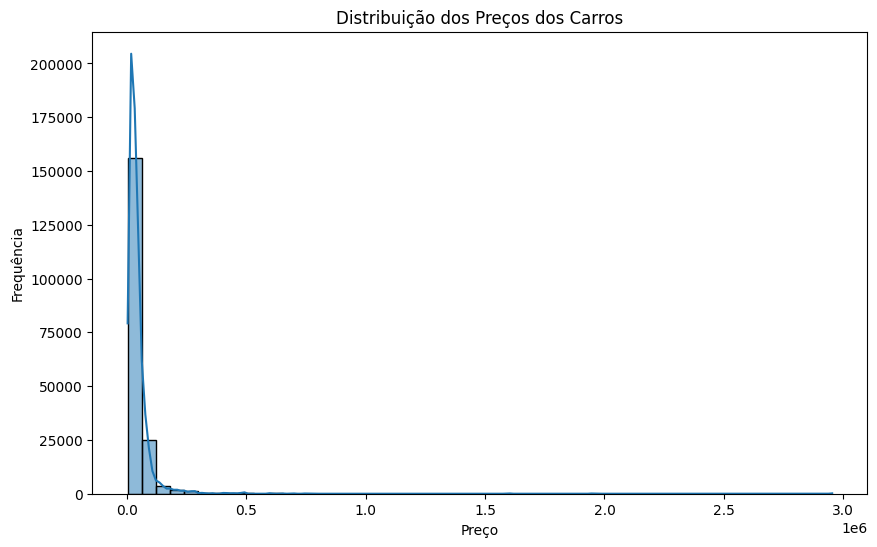

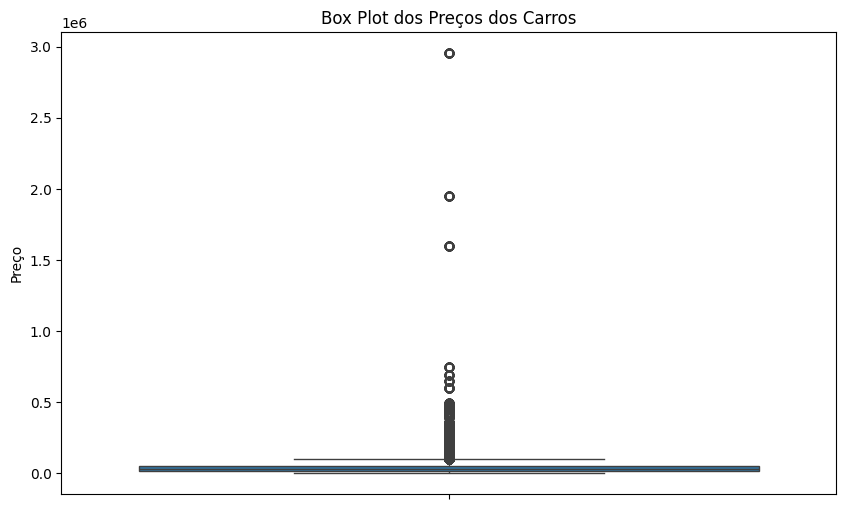

In [ ]:
print('Estatísticas Descritivas da Variável Alvo (price):')
print(train_df['price'].describe())

# Plotar histograma da variável alvo
plt.figure(figsize=(10, 6))
sns.histplot(train_df['price'], bins=50, kde=True)
plt.title('Distribuição dos Preços dos Carros')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

# Plotar box plot da variável alvo
plt.figure(figsize=(10, 6))
sns.boxplot(y=train_df['price'])
plt.title('Box Plot dos Preços dos Carros')
plt.ylabel('Preço')
plt.show()




## Preparação dos Dados


### Criação da divisão de treino e teste

Antes de treinar o modelo, dividimos os dados em conjuntos de treino e teste. O conjunto de treino é usado para ensinar o modelo, e o conjunto de teste é usado para avaliar seu desempenho em dados que ele nunca viu, garantindo uma avaliação imparcial e realista.

In [ ]:
#Separar dataframe em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_df.drop('price', axis=1),
    train_df['price'],
    test_size=0.2,
    random_state=27
)

### Engenharia de Features e Pré-processamento

### Função de preprocessamento

Esta função é responsável por extrair características complexas da coluna 'engine', que contém uma descrição textual do motor do carro. Ela parseia informações como potência (HP), cilindrada, número de válvulas e cilindros, tipo de layout, presença de turbo, supercharger, tecnologias específicas (DOHC, SOHC, GDI, etc.), e tipo de combustível ou eletrificação. Ao final, ela transforma essas informações textuais em novas colunas numéricas e categóricas, tornando-as utilizáveis pelo modelo. Além disso, a função inclui um imputer para tratar valores ausentes em colunas categóricas específicas, preenchendo-os com 'Missing'.

In [ ]:
import re
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer # Import SimpleImputer, though a custom one will be used


class EngineFeatureExtractor(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        engine_column="engine",
        drop_original=True,
        debug=False
    ):
        self.engine_column = engine_column
        self.drop_original = drop_original
        self.debug = debug

    def fit(self, X, y=None):
        return self

    def transform(self, X):

      X = X.copy()

      engine = X[self.engine_column].fillna("").astype(str)

      # ==================================================
      # Coluna auxiliar para descobrir padrões não tratados
      # ==================================================
      remaining = engine.copy()

      # -----------------------
      # HP
      # -----------------------
      X["engine_hp"] = (
          engine.str.extract(
              r'(\d+\.?\d*)HP',
              expand=False
          )
          .astype(float)
      )

      remaining = remaining.str.replace(
          r'\d+\.?\d*HP',
          '',
          regex=True
      )

      # -----------------------
      # Cilindrada
      # Captura:
      # 2.0L
      # 2.0 Liter
      # -----------------------
      X["engine_displacement"] = (
          engine.str.extract(
              r'(\d+\.?\d*)\s*(?:Liter|L)',
              expand=False
          )
          .astype(float)
      )

      remaining = remaining.str.replace(
          r'\d+\.?\d*\s*(?:L|Liter)',
          '',
          regex=True,
          case=False
      )

      # -----------------------
      # Número de válvulas
      # -----------------------
      X["engine_valves"] = (
          engine.str.extract(
              r'(\d+)V',
              expand=False
          )
          .astype(float)
      )

      remaining = remaining.str.replace(
          r'\d+V',
          '',
          regex=True,
          case=False
      )

      # -----------------------
      # Número de cilindros
      # -----------------------
      cyl = engine.str.extract(
          r'(\d+)\s*Cylinder|V(\d+)|I(\d+)|H(\d+)|Straight\s*(\d+)|Flat\s*(\d+)',
          flags=re.IGNORECASE
      )

      X["engine_cylinders"] = (
          cyl.bfill(axis=1)
          .iloc[:, 0]
          .astype(float)
      )

      remaining = remaining.str.replace(
          r'\d+\s*Cylinder',
          '',
          regex=True,
          case=False
      )

      remaining = remaining.str.replace(
          r'V\d+',
          '',
          regex=True,
          case=False
      )

      remaining = remaining.str.replace(
          r'I\d+',
          '',
          regex=True,
          case=False
      )

      remaining = remaining.str.replace(
          r'H\d+',
          '',
          regex=True,
          case=False
      )

      remaining = remaining.str.replace(
          r'Straight\s*\d+',
          '',
          regex=True,
          case=False
      )

      remaining = remaining.str.replace(
          r'Flat\s*\d+',
          '',
          regex=True,
          case=False
      )

      # -----------------------
      # Layout
      # -----------------------
      X["engine_layout"] = np.select(
          [
              engine.str.contains(
                  r'\bV\d+\b',
                  case=False,
                  na=False,
                  regex=True
              ),
              engine.str.contains(
                  r'\bI\d+\b',
                  case=False,
                  na=False,
                  regex=True
              ),
              engine.str.contains(
                  r'\bH\d+\b',
                  case=False,
                  na=False,
                  regex=True
              ),
              engine.str.contains(
                  r'Straight',
                  case=False,
                  na=False
              ),
              engine.str.contains(
                  r'Flat',
                  case=False,
                  na=False
              ),
          ],
          [
              "V",
              "Inline",
              "Boxer",
              "Straight",
              "Flat",
          ],
          default="Unknown"
      )

      remaining = remaining.str.replace(
          r'\bV\b',
          '',
          regex=True
      )

      remaining = remaining.str.replace(
          r'\bStraight\b',
          '',
          regex=True,
          case=False
      )

      remaining = remaining.str.replace(
          r'\bFlat\b',
          '',
          regex=True,
          case=False
      )

      # -----------------------
      # Turbo
      # -----------------------
      X["engine_turbo"] = (
          engine.str.contains(
              'Turbo',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_twin_turbo"] = (
          engine.str.contains(
              'Twin Turbo',
              case=False,
              na=False
          )
          .astype(int)
      )

      remaining = remaining.str.replace(
          'Twin Turbo',
          '',
          regex=False
      )

      remaining = remaining.str.replace(
          'Turbo',
          '',
          regex=False
      )

      # -----------------------
      # Supercharged
      # -----------------------
      X["engine_supercharged"] = (
          engine.str.contains(
              'Supercharged',
              case=False,
              na=False
          )
          .astype(int)
      )

      remaining = remaining.str.replace(
          'Supercharged',
          '',
          regex=False
      )

      # -----------------------
      # DOHC / SOHC / OHV
      # -----------------------
      X["engine_dohc"] = (
          engine.str.contains(
              'DOHC',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_sohc"] = (
          engine.str.contains(
              'SOHC',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_ohv"] = (
          engine.str.contains(
              'OHV',
              case=False,
              na=False
          )
          .astype(int)
      )

      remaining = remaining.str.replace(
          'DOHC',
          '',
          regex=False
      )

      remaining = remaining.str.replace(
          'SOHC',
          '',
          regex=False
      )

      remaining = remaining.str.replace(
          'OHV',
          '',
          regex=False
      )

      # -----------------------
      # Tecnologias
      # -----------------------
      for tech in ["GDI", "PDI", "TFSI", "MPFI", "DDI"]:
          X[f"engine_{tech.lower()}"] = (
              engine.str.contains(
                  tech,
                  case=False,
                  na=False
              )
              .astype(int)
          )

          remaining = remaining.str.replace(
              tech,
              '',
              regex=False
          )

      # -----------------------
      # Combustível / eletrificação
      # -----------------------
      X["engine_electric"] = (
          engine.str.contains(
              'Electric',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_hybrid"] = (
          engine.str.contains(
              'Hybrid',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_mild_hybrid"] = (
          engine.str.contains(
              'Mild Electric Hybrid',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_plugin_hybrid"] = (
          engine.str.contains(
              'Plug-In',
              case=False,
              na=False
          )
          .astype(int)
      )

      X["engine_flex_fuel"] = (
          engine.str.contains(
              'Flex Fuel',
              case=False,
              na=False
          )
          .astype(int)
      )

      fuel_patterns = [
          'Gasoline Fuel',
          'Diesel Fuel',
          'Electric Fuel System',
          'Electric Motor',
          'Gas/Electric Hybrid',
          'Gasoline/Mild Electric Hybrid',
          'Mild Electric Hybrid',
          'Plug-In Electric/Gas',
          'Flex Fuel Capability',
          'Electric',
          'Hybrid'
      ]

      for p in fuel_patterns:
          remaining = remaining.str.replace(
              p,
              '',
              regex=False
          )

      # -----------------------
      # Texto genérico
      # -----------------------
      remaining = remaining.str.replace(
          'Engine',
          '',
          regex=False
      )

      # -----------------------
      # Limpeza final
      # -----------------------
      remaining = (
          remaining
          .str.replace(r'\s+', ' ', regex=True)
          .str.strip()
      )

      self.remaining_engine_ = remaining

      if self.debug:

          leftovers = (
              remaining[remaining != ""]
              .value_counts()
              .head(50)
          )

          print("\n===== ENGINE LEFTOVERS =====\n")
          print(leftovers)

      #X["engine_remaining"] = remaining

      if self.drop_original:
          X = X.drop(columns=[self.engine_column])

      return X


class CategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, columns, fill_value='Missing'):
        self.columns = columns
        self.fill_value = fill_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].fillna(self.fill_value)
        return X_copy

### Instalação de Dependências

Para garantir que todas as bibliotecas necessárias para o treinamento do modelo estejam disponíveis, instalamos o pacote `catboost`, que é a implementação do algoritmo Gradient Boosting que utilizaremos neste notebook.

In [ ]:
!pip install catboost

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

# ==================================================
# Pré-processamento
# ==================================================

preprocessing_pipeline = Pipeline([
    ("engine_features", EngineFeatureExtractor()),
    ("categorical_imputer", CategoricalImputer(columns=["fuel_type", "accident", "clean_title"], fill_value='Missing'))
])

X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)


# ==================================================
# Colunas categóricas para o CatBoost
# ==================================================

cat_features = [
    "brand",
    "model",
    "fuel_type",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title",
    "engine_layout",
    #"engine_remaining"
]

# Mantém apenas as que realmente existem
cat_features = [
    col for col in cat_features
    if col in X_train_processed.columns
]

# ==================================================
# Modelo base
# ==================================================

model = CatBoostRegressor(
    loss_function="RMSE",
    random_state=42,
    verbose=0
)

# ==================================================
# Espaço de busca
# ==================================================

param_dist = {
    "depth": [4, 5, 6, 7, 8, 9, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [300, 500, 800, 1000, 1500],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "bagging_temperature": [0, 0.25, 0.5, 1, 2],
}

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Neste bloco, configuramos a `preprocessing_pipeline` combinando o `EngineFeatureExtractor` (que cria novas características a partir da descrição do motor) e o `CategoricalImputer` (que preenche valores ausentes em colunas categóricas). Em seguida, essa pipeline é aplicada aos conjuntos de treino (`X_train`) e teste (`X_test`) para gerar os dados pré-processados (`X_train_processed` e `X_test_processed`), que serão usados para treinar e avaliar o modelo.

### Otimização de Hiperparâmetros com RandomizedSearchCV

Nesta etapa, utilizamos o `RandomizedSearchCV` para otimizar os hiperparâmetros do nosso modelo `CatBoostRegressor`. Em vez de testar todas as combinações (como no `GridSearchCV`), o `RandomizedSearchCV` explora aleatoriamente uma parte do espaço de busca definido em `param_dist`. Isso nos permite encontrar bons conjuntos de hiperparâmetros de forma mais eficiente, especialmente com muitos parâmetros ou um espaço de busca grande. O processo envolve o treinamento do modelo com diferentes combinações de parâmetros e a seleção daquela que oferece o melhor desempenho, conforme medido pela métrica 'neg_root_mean_squared_error'.

In [ ]:
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(
    X_train_processed,
    y_train,
    cat_features=cat_features
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 0.25, 0.5, 1,
                                                                2],
                                        'depth': [4, 5, 6, 7, 8, 9, 10],
                                        'iterations': [300, 500, 800, 1000,
                                                       1500],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

### Avaliação do Melhor Modelo

Após a execução do `RandomizedSearchCV`, identificamos o conjunto de hiperparâmetros que resultou no melhor desempenho para o nosso modelo. O melhor modelo encontrado é então armazenado para uso posterior, e apresentamos os seus hiperparâmetros ótimos e o RMSE (Root Mean Squared Error) médio obtido durante a validação cruzada.

In [ ]:
print("Melhores parâmetros:")
print(search.best_params_)

print("\nMelhor RMSE CV:")
print(-search.best_score_)

Melhores parâmetros:
{'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 10, 'bagging_temperature': 2}

Melhor RMSE CV:
70828.97594285558


In [ ]:
best_model = search.best_estimator_

## Predição

### Realização de Predições e Avaliação de Métricas

Com o melhor modelo selecionado, realizamos predições no conjunto de teste (`X_test_processed`). Em seguida, avaliamos o desempenho dessas predições utilizando três métricas de regressão importantes: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) e R² (Coeficiente de Determinação). Essas métricas nos fornecem uma compreensão clara da precisão e do poder explicativo do modelo em dados não vistos.

In [ ]:
y_pred = best_model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np # Ensure numpy is imported for sqrt

mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error first
mse = mean_squared_error(y_test, y_pred)
# Then take the square root to get RMSE
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  19818.07
RMSE: 79822.91
R²:   0.1310


### Geração do Arquivo de Submissão

Finalmente, usamos o modelo treinado para gerar predições no conjunto de dados de competição (`test_df`). As predições são formatadas em um DataFrame com as colunas 'id' e 'price', conforme exigido para a submissão, e o arquivo CSV resultante é salvo tanto localmente quanto no Google Drive para garantir a persistência e facilitar o upload.

In [ ]:
X_competition = preprocessing_pipeline.transform(test_df)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
competition_predictions = best_model.predict(X_competition)

In [ ]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "price": competition_predictions
})

In [ ]:
len(submission)

125690

In [ ]:
#Salvar a submissão no google drive
import os

path_output = '/content/drive/MyDrive/Estudos/0-Ifes-Mestrado/Reconhecimento de Padrões/Trabalho-Final/output/'

os.makedirs(path_output, exist_ok=True)

submission.to_csv(
    path_output + 'submission.csv',
    index=False
)


#submission.to_csv("submission.csv", index=False)